# 10 · Forecasted Weather → Bike Demand Forecast

## tl;dr

本 Notebook 用同一批起报点，比较 **Oracle Weather / Forecasted Weather / No Future Weather**。Forecasted Weather 的天气值由起报时刻以前的信息产生，再交给 Direct 与 Recursive 需求模型；这是三个场景中最接近部署逻辑的实验。**结果并非单向改善：**60 起点主样本上，72h Direct 的 Forecasted MAE 为 3355.36，高于 No-weather 的 2877.65；72/168h 的 Forecasted 模型均未超过 Weekly Naive。改用 672 个共同目标小时后，Forecasted Recursive 在 72/168h 超过 Weekly Naive，说明取样口径会改变长 horizon 结论。

**阅读顺序：**天气字段审计 → 天气预测与泄漏审计 → 需求三场景 → Oracle Gap Recovery → 误差传播与高峰 → 稳健性与结论。

## Context & Methods · 与 07–09 保持同一实验边界

- 需求目标：`ride_count`（每小时骑行次数）；horizon：1、3、6、12、24、48、72、168 小时。
- 保持 09 的固定 80/20 时间切分、60 个每日预测起点和 672 个共同目标小时。07–09 **没有单独的 validation 切分**，这里也不新造一个。
- 需求 HGB 参数与 `random_state=42` 保持 09 原样；天气 HGB 用固定、较轻的参数，无超参搜索。MAE、RMSE 单位为 rides/hour；Mean Error = actual − prediction，正值表示低估。
- **A Oracle Weather：**需求预测使用目标时刻真实天气，重现 09 的 Oracle 条件。
- **B No Future Weather：**需求预测完全不使用未来天气，重现 09 的 Realistic 条件。
- **C Forecasted Weather：**需求预测目标时刻只使用天气模型输出。训练需求模型时也使用按时间顺序产生的天气预测：最早一段用 168h 天气季节朴素预测作 warm-up，随后用仅在各起报点之前完成训练的 expanding-window HGB。测试期天气模型只在测试开始以前的天气标签上拟合。

**可用信息：**起报时刻为 `t`，第一个未来小时为 `t+1`，horizon `h` 的目标是 `t+h`。目标日历可以预知；历史天气和需求截至 `t`；`t+h` 的真实天气和需求只能用于事后评分。对测试期后续起报点，已过去的测试期观测天气仍是合法历史输入。

**递归天气路径：**每个已报告的 horizon 使用对应的 Direct HGB 天气模型。在未报告的中间小时，使用 h=1 天气模型逐小时递归产生天气；已报告的锚点预测会回填进这条天气路径。这样 Direct 与 Recursive 在每个评分终点读取同一份天气预测，且 168 步途中没有真实未来天气。Recursive 还会回填自身预测需求，所以它同时承受天气误差与需求误差传播。

## Data · 读取 09 所用的处理后小时序列

先在完整连续小时轴上建立历史 lag，再排除 09 的两个夏令时建模小时。春季缺失天气占位只用其之前一小时的天气向前填充，绝不从未来回填。保留它在原始审计中的缺失统计。

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

HORIZONS = (1, 3, 6, 12, 24, 48, 72, 168)
FOCUS_HORIZONS = (24, 72, 168)
WEATHER_COLUMNS = (
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"
)
WEATHER_UNITS = {
    "temperature_2m": "°C", "relative_humidity_2m": "percentage points",
    "precipitation": "mm", "wind_speed_10m": "km/h",
}
DEMAND_COLUMNS = ["lag_1", "lag_24", "lag_168", "rolling_mean_3", "rolling_mean_6"]
DEMAND_MODEL_PARAMETERS = {
    "max_iter": 240, "learning_rate": 0.07, "max_leaf_nodes": 31,
    "min_samples_leaf": 25, "l2_regularization": 0.1,
    "early_stopping": False, "random_state": 42,
}
WEATHER_MODEL_PARAMETERS = {
    "max_iter": 100, "learning_rate": 0.07, "max_leaf_nodes": 15,
    "min_samples_leaf": 30, "l2_regularization": 0.1,
    "early_stopping": False, "random_state": 42,
}
PALETTE = {
    "Oracle": "#285B75", "Forecasted Weather": "#C56B42",
    "No Future Weather": "#9A8B6B", "Weekly Naive": "#4A4A4A",
    "Recursive": "#285B75", "Direct": "#C56B42",
}
plt.rcParams.update({
    "figure.figsize": (11, 5), "font.size": 10, "axes.spines.top": False,
    "axes.spines.right": False, "savefig.dpi": 130,
})

project_root = Path.cwd()
if not (project_root / "data" / "processed" / "bikeflow_2024.csv").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "processed" / "bikeflow_2024.csv"
assert data_path.exists(), f"未找到数据：{data_path}"
data = pd.read_csv(data_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
assert len(data) == 8784 and data["timestamp"].is_unique
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
assert data["ride_count"].notna().all()

for lag in (1, 24, 168):
    data[f"lag_{lag}"] = data["ride_count"].shift(lag)
for window in (3, 6):
    data[f"rolling_mean_{window}"] = data["ride_count"].shift(1).rolling(
        window, min_periods=window
    ).mean()

spring_gap = pd.Timestamp("2024-03-10 02:00")
fall_repeat = pd.Timestamp("2024-11-03 01:00")
model_data = data.loc[~data["timestamp"].isin([spring_gap, fall_repeat])].copy().reset_index(drop=True)
split_index = int(len(model_data) * 0.8)
fixed_test_start = model_data.loc[split_index, "timestamp"]
test_end = model_data["timestamp"].iloc[-1]
assert len(model_data) == 8782 and split_index == 7025
assert fixed_test_start == pd.Timestamp("2024-10-19 18:00")
assert test_end == pd.Timestamp("2024-12-31 23:00")

observed_demand = data.set_index("timestamp")["ride_count"]
print(f"来源：{data_path}")
print(f"连续小时：{len(data):,}；建模小时：{len(model_data):,}")
print(f"训练标签 < {fixed_test_start}；测试目标 ≤ {test_end}；无单独 validation")

来源：C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
连续小时：8,784；建模小时：8,782
训练标签 < 2024-10-19 18:00:00；测试目标 ≤ 2024-12-31 23:00:00；无单独 validation


## Weather Feature Audit · 只从真实存在的字段中选择

下表列出处理后数据中的全部天气字段，并区别“存储 dtype”和变量含义。为了和 09 的 47 列 Oracle 模型严格可比，本次需求模型仍只使用 09 的四个天气字段。`apparent_temperature` 与温度高度重合，`rain` 与 `precipitation` 高度重合，`snowfall` 极稀疏；`weather_code` 虽存为数字，却是类别代码，若使用应做分类/独热处理，不能当连续数值回归。本实验不把这些字段偷偷加进模型。

In [2]:
weather_fields_found = [
    column for column in pd.read_csv(data_path, nrows=0).columns
    if column not in {"timestamp", "ride_count"}
]
assert set(WEATHER_COLUMNS).issubset(weather_fields_found)
weather_audit_rows = []
for variable in weather_fields_found:
    is_categorical = variable == "weather_code"
    weather_audit_rows.append({
        "Variable": variable,
        "Data type": "categorical code (stored numeric)" if is_categorical else str(data[variable].dtype),
        "Missing rate %": 100 * data[variable].isna().mean(),
        "Available historically": "Yes",
        "Needs forecasting if used": "Yes" if variable in WEATHER_COLUMNS else "Excluded (09 parity)",
        "Used in 10": "Yes" if variable in WEATHER_COLUMNS else "No",
    })
weather_feature_audit = pd.DataFrame(weather_audit_rows)
display(weather_feature_audit.round(4))
print("09/10 demand weather inputs:", ", ".join(WEATHER_COLUMNS))
print("weather_code observed categories:", data["weather_code"].dropna().nunique())

observed_weather_raw = data.set_index("timestamp")[list(WEATHER_COLUMNS)]
observed_weather = observed_weather_raw.ffill()
assert observed_weather.notna().all(axis=None)
assert observed_weather_raw.loc[spring_gap].isna().all()
assert observed_weather.loc[spring_gap].equals(observed_weather.loc[spring_gap - pd.Timedelta(hours=1)])

,Variable,Data type,Missing rate %,Available historically,Needs forecasting if used,Used in 10
0,temperature_2m,float64,0.0114,Yes,Yes,Yes
1,apparent_temperature,float64,0.0114,Yes,Excluded (09 parity),No
2,relative_humidity_2m,float64,0.0114,Yes,Yes,Yes
3,precipitation,float64,0.0114,Yes,Yes,Yes
4,rain,float64,0.0114,Yes,Excluded (09 parity),No
5,snowfall,float64,0.0114,Yes,Excluded (09 parity),No
6,weather_code,categorical code (stored numeric),0.0114,Yes,Excluded (09 parity),No
7,wind_speed_10m,float64,0.0114,Yes,Yes,Yes


09/10 demand weather inputs: temperature_2m, relative_humidity_2m, precipitation, wind_speed_10m
weather_code observed categories: 13


## Paired origins · 复原 09 的日历、需求 lag 与评分样本

日历是目标时刻已知信息；需求 lag 和 rolling 固定在起报时刻。为保证三场景对比只改变未来天气可用性，Oracle、No Future Weather 与 Forecasted Weather 共享完全相同的标签、需求历史列和评估起点。

In [3]:
target_calendar = pd.DataFrame({
    "target_hour": pd.Categorical(model_data["timestamp"].dt.hour, categories=range(24)),
    "target_day_of_week": pd.Categorical(model_data["timestamp"].dt.dayofweek, categories=range(7)),
    "target_month": pd.Categorical(model_data["timestamp"].dt.month, categories=range(1, 13)),
})
calendar_dummies_all = pd.get_dummies(target_calendar, drop_first=True, dtype=int)
training_calendar_mask = model_data["timestamp"] < fixed_test_start
calendar_columns = calendar_dummies_all.loc[
    training_calendar_mask
].columns[calendar_dummies_all.loc[training_calendar_mask].any(axis=0)].tolist()
assert len(calendar_columns) == 38
calendar_target = calendar_dummies_all[calendar_columns].copy()
calendar_target.index = pd.DatetimeIndex(model_data["timestamp"])

weather_target = model_data[list(WEATHER_COLUMNS)].copy()
weather_target.index = calendar_target.index
origin_demand = model_data[DEMAND_COLUMNS].copy()
origin_demand.index = calendar_target.index
valid_history = model_data[DEMAND_COLUMNS].notna().all(axis=1)

first_future_candidates = pd.DatetimeIndex(model_data.loc[valid_history, "timestamp"])
training_specs = {}
expected_training_counts = (6857, 6854, 6851, 6845, 6833, 6809, 6785, 6689)
for horizon, expected_count in zip(HORIZONS, expected_training_counts):
    target_times = first_future_candidates + pd.Timedelta(hours=horizon - 1)
    use = (
        target_times.isin(calendar_target.index)
        & (target_times < fixed_test_start)
        & (first_future_candidates < fixed_test_start)
    )
    train_first, train_targets = first_future_candidates[use], target_times[use]
    assert len(train_targets) == expected_count
    training_specs[horizon] = (train_first, train_targets)

test_valid_times = set(model_data.loc[
    (model_data["timestamp"] >= fixed_test_start) & valid_history, "timestamp"
])
candidate_origins = pd.date_range(
    fixed_test_start, test_end - pd.Timedelta(hours=167), freq="24h"
)
first_future_origins = pd.DatetimeIndex([
    first_future for first_future in candidate_origins
    if all(target in test_valid_times for target in pd.date_range(first_future, periods=168, freq="h"))
])
common_target_times = pd.date_range("2024-11-18 00:00", "2024-12-15 23:00", freq="h")
assert len(candidate_origins) == 67 and len(first_future_origins) == 60
assert len(common_target_times) == 672 and common_target_times.isin(calendar_target.index).all()
assert common_target_times.min() - pd.Timedelta(hours=167) >= fixed_test_start

display(pd.DataFrame({
    "Horizon (h)": HORIZONS,
    "Pre-test training pairs": [len(training_specs[h][0]) for h in HORIZONS],
    "Main paired test points": 60,
}))
print("共同目标小时：", common_target_times.min(), "至", common_target_times.max())

,Horizon (h),Pre-test training pairs,Main paired test points
0,1,6857,60
1,3,6854,60
2,6,6851,60
3,12,6845,60
4,24,6833,60
5,48,6809,60
6,72,6785,60
7,168,6689,60


共同目标小时： 2024-11-18 00:00:00 至 2024-12-15 23:00:00


## Weather Forecasting · 从起报点历史预测 `weather(t+h)`

天气 Direct HGB 的每个输入行由**目标日历**和**起报时刻以前的天气历史**组成。天气 lag 采用 1/3/6/24/48/168 小时；rolling mean/std 对 `shift(1)` 后的天气做 3/6/24 小时窗口。周期日历帮助模型学习季节与时段，但不会提供目标真实天气。

In [4]:
WEATHER_LAGS = (1, 3, 6, 24, 48, 168)
WEATHER_ROLLING_WINDOWS = (3, 6, 24)
weather_history_features = pd.DataFrame(index=observed_weather.index)
for variable in WEATHER_COLUMNS:
    for lag in WEATHER_LAGS:
        weather_history_features[f"{variable}_lag_{lag}"] = observed_weather[variable].shift(lag)
    prior_weather = observed_weather[variable].shift(1)
    for window in WEATHER_ROLLING_WINDOWS:
        weather_history_features[f"{variable}_roll_mean_{window}"] = prior_weather.rolling(
            window, min_periods=window
        ).mean()
        weather_history_features[f"{variable}_roll_std_{window}"] = prior_weather.rolling(
            window, min_periods=window
        ).std(ddof=0)

weather_calendar = calendar_target.copy()
target_index = weather_calendar.index
weather_calendar["weather_target_weekend"] = (target_index.dayofweek >= 5).astype(int)
weather_calendar["weather_target_hour_sin"] = np.sin(2 * np.pi * target_index.hour / 24)
weather_calendar["weather_target_hour_cos"] = np.cos(2 * np.pi * target_index.hour / 24)
weather_calendar["weather_target_doy_sin"] = np.sin(2 * np.pi * target_index.dayofyear / 366)
weather_calendar["weather_target_doy_cos"] = np.cos(2 * np.pi * target_index.dayofyear / 366)
WEATHER_INPUT_COLUMNS = list(weather_calendar.columns) + list(weather_history_features.columns)

def make_weather_matrix(first_future_times, target_times):
    first_future_times = pd.DatetimeIndex(first_future_times)
    target_times = pd.DatetimeIndex(target_times)
    assert len(first_future_times) == len(target_times)
    origin = first_future_times - pd.Timedelta(hours=1)
    assert (target_times > origin).all()
    calendar_part = weather_calendar.loc[target_times].reset_index(drop=True)
    history_part = weather_history_features.loc[first_future_times].reset_index(drop=True)
    matrix = pd.concat([calendar_part, history_part], axis=1)[WEATHER_INPUT_COLUMNS]
    assert matrix.notna().all(axis=None) and np.isfinite(matrix.to_numpy()).all()
    return matrix

def weather_seasonal_naive(first_future_times, target_times, season_hours=168):
    first_future_times = pd.DatetimeIndex(first_future_times)
    target_times = pd.DatetimeIndex(target_times)
    source_times = target_times - pd.Timedelta(hours=season_hours)
    origins = first_future_times - pd.Timedelta(hours=1)
    assert (source_times <= origins).all(), "seasonal baseline cannot read post-origin weather"
    result = observed_weather.reindex(source_times).reset_index(drop=True)
    assert result.notna().all(axis=None)
    return result

example_first, example_target = training_specs[24]
print(f"Weather input columns: {len(WEATHER_INPUT_COLUMNS)}; sample train matrix: {make_weather_matrix(example_first[:3], example_target[:3]).shape}")

Weather input columns: 91; sample train matrix: (3, 91)


## Weather Leakage Audit · 逐项断言时间边界

这里检查实际传给天气模型的 lag/rolling 来源，而不是仅检查列名。测试目标真实天气不在任何输入矩阵中；它只在天气评分时读取。训练标签必须在固定测试起点之前。`t+h−168h` 对全部所选 horizon 都不晚于起报时刻；24h 季节朴素预测只可用于 `h≤24`，因此不作为通用基线。

In [5]:
def weather_leakage_audit():
    audit_rows = []
    for horizon in HORIZONS:
        train_first, train_target = training_specs[horizon]
        test_first = first_future_origins
        test_target = test_first + pd.Timedelta(hours=horizon - 1)
        assert (train_target == train_first + pd.Timedelta(hours=horizon - 1)).all()
        assert (test_target == test_first + pd.Timedelta(hours=horizon - 1)).all()
        assert (train_target < fixed_test_start).all()
        assert (test_first >= fixed_test_start).all() and (test_target <= test_end).all()
        for first_future, target in ((train_first, train_target), (test_first, test_target)):
            origin = first_future - pd.Timedelta(hours=1)
            assert (target > origin).all()
            matrix = make_weather_matrix(first_future, target)
            assert set(matrix.columns).isdisjoint(WEATHER_COLUMNS)
            for lag in WEATHER_LAGS:
                source = first_future - pd.Timedelta(hours=lag)
                assert (source <= origin).all()
                for variable in WEATHER_COLUMNS:
                    measured = matrix[f"{variable}_lag_{lag}"].to_numpy()
                    expected = observed_weather[variable].reindex(source).to_numpy()
                    assert np.allclose(measured, expected)
            for window in WEATHER_ROLLING_WINDOWS:
                latest_source = first_future - pd.Timedelta(hours=1)
                assert (latest_source == origin).all()
                for variable in WEATHER_COLUMNS:
                    prior_values = np.column_stack([
                        observed_weather[variable].reindex(
                            first_future - pd.Timedelta(hours=back)
                        ).to_numpy()
                        for back in range(1, window + 1)
                    ])
                    assert np.allclose(
                        matrix[f"{variable}_roll_mean_{window}"].to_numpy(),
                        prior_values.mean(axis=1),
                    )
                    assert np.allclose(
                        matrix[f"{variable}_roll_std_{window}"].to_numpy(),
                        prior_values.std(axis=1, ddof=0),
                        atol=1e-5, rtol=1e-6,
                    )
            weather_seasonal_naive(first_future, target)
        audit_rows.append({
            "Horizon": horizon, "Lag sources ≤ origin": "PASS",
            "Rolling excludes target": "PASS", "Direct label = t+h": "PASS",
            "Train/test chronology": "PASS", "Test target absent from X": "PASS",
        })
    return pd.DataFrame(audit_rows)

weather_leakage_audit_table = weather_leakage_audit()
display(weather_leakage_audit_table)

,Horizon,Lag sources ≤ origin,Rolling excludes target,Direct label = t+h,Train/test chronology,Test target absent from X
0,1,PASS,PASS,PASS,PASS,PASS
1,3,PASS,PASS,PASS,PASS,PASS
2,6,PASS,PASS,PASS,PASS,PASS
3,12,PASS,PASS,PASS,PASS,PASS
4,24,PASS,PASS,PASS,PASS,PASS
5,48,PASS,PASS,PASS,PASS,PASS
6,72,PASS,PASS,PASS,PASS,PASS
7,168,PASS,PASS,PASS,PASS,PASS


## Weather models · 每个 horizon × 每个天气变量一个 Direct HGB

这些模型只在测试开始以前的天气标签上拟合。四个目标分别训练，避免复杂的多输出模型；参数一次固定，不根据测试分数调参。天气季节朴素预测作为可解释基线。

In [6]:
weather_models = {}
for horizon in HORIZONS:
    train_first, train_target = training_specs[horizon]
    train_matrix = make_weather_matrix(train_first, train_target)
    weather_models[horizon] = {}
    for variable in WEATHER_COLUMNS:
        label = weather_target.loc[train_target, variable].to_numpy()
        fitted = HistGradientBoostingRegressor(**WEATHER_MODEL_PARAMETERS)
        fitted.fit(train_matrix, label)
        weather_models[horizon][variable] = fitted
    print(f"Weather HGB trained: h={horizon:>3}h, variables={len(WEATHER_COLUMNS)}")
assert len(weather_models) == len(HORIZONS)

PREDICTED_WEATHER_COLUMNS = [f"{variable}_pred" for variable in WEATHER_COLUMNS]

def predict_weather_direct(first_future_times, target_times, horizon):
    first_future_times = pd.DatetimeIndex(first_future_times)
    target_times = pd.DatetimeIndex(target_times)
    assert (target_times == first_future_times + pd.Timedelta(hours=horizon - 1)).all()
    matrix = make_weather_matrix(first_future_times, target_times)
    prediction = pd.DataFrame({
        f"{variable}_pred": weather_models[horizon][variable].predict(matrix)
        for variable in WEATHER_COLUMNS
    })
    assert np.isfinite(prediction.to_numpy()).all()
    return prediction

Weather HGB trained: h=  1h, variables=4


Weather HGB trained: h=  3h, variables=4


Weather HGB trained: h=  6h, variables=4


Weather HGB trained: h= 12h, variables=4


Weather HGB trained: h= 24h, variables=4


Weather HGB trained: h= 48h, variables=4


Weather HGB trained: h= 72h, variables=4


Weather HGB trained: h=168h, variables=4


## Weather Forecast Evaluation · 先看天气，再看需求

主表使用 60 个与需求评分完全相同的起点。对每个变量报告天气 MAE、RMSE、Bias（actual − predicted），并比较 168h 季节朴素预测。不同天气变量单位不同，因此“最容易预测”主要看相对于该变量季节朴素基线的改进率，而不是跨单位直接比较 MAE。

In [7]:
def score_predictions(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    assert len(actual) == len(predicted) and np.isfinite(actual).all() and np.isfinite(predicted).all()
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "Mean Error": np.mean(actual - predicted),
    }

weather_main_rows = []
weather_metric_rows = []
for horizon in HORIZONS:
    first_future = first_future_origins
    target_times = first_future + pd.Timedelta(hours=horizon - 1)
    predicted = predict_weather_direct(first_future, target_times, horizon)
    seasonal = weather_seasonal_naive(first_future, target_times)
    actual = weather_target.loc[target_times].reset_index(drop=True)
    for position, (origin, target) in enumerate(zip(first_future, target_times)):
        row = {"Horizon": horizon, "First Future Hour": origin, "Target Timestamp": target}
        for variable in WEATHER_COLUMNS:
            row[f"{variable}_actual"] = actual.loc[position, variable]
            row[f"{variable}_pred"] = predicted.loc[position, f"{variable}_pred"]
        weather_main_rows.append(row)
    for variable in WEATHER_COLUMNS:
        actual_values = actual[variable].to_numpy()
        hgb_scores = score_predictions(actual_values, predicted[f"{variable}_pred"])
        seasonal_scores = score_predictions(actual_values, seasonal[variable])
        weather_metric_rows.append({
            "Horizon": horizon, "Variable": variable, "Unit": WEATHER_UNITS[variable],
            "Seasonal Naive MAE": seasonal_scores["MAE"],
            "HGB MAE": hgb_scores["MAE"], "HGB RMSE": hgb_scores["RMSE"],
            "HGB Bias": hgb_scores["Mean Error"],
            "HGB skill vs seasonal %": 100 * (1 - hgb_scores["MAE"] / seasonal_scores["MAE"]),
            "Points": len(first_future),
        })
weather_main_panel = pd.DataFrame(weather_main_rows)
weather_metrics = pd.DataFrame(weather_metric_rows)
assert len(weather_main_panel) == 60 * len(HORIZONS)
assert weather_metrics["Points"].eq(60).all()
display(weather_metrics.round(3))

,Horizon,Variable,Unit,Seasonal Naive MAE,HGB MAE,HGB RMSE,HGB Bias,HGB skill vs seasonal %,Points
0,1,temperature_2m,°C,5.350,0.682,0.911,0.165,87.262,60
1,1,relative_humidity_2m,percentage points,17.783,2.949,4.170,-2.087,83.417,60
2,1,precipitation,mm,0.230,0.073,0.326,0.033,68.360,60
3,1,wind_speed_10m,km/h,4.943,1.733,2.105,0.168,64.935,60
4,3,temperature_2m,°C,4.917,1.425,1.778,0.749,71.024,60
5,3,relative_humidity_2m,percentage points,16.550,8.203,10.107,-6.746,50.438,60
6,3,precipitation,mm,0.188,0.152,0.475,0.063,19.515,60
7,3,wind_speed_10m,km/h,4.942,2.445,3.379,-0.223,50.516,60
8,6,temperature_2m,°C,4.955,1.807,2.415,0.768,63.523,60
9,6,relative_humidity_2m,percentage points,16.950,9.169,11.808,-6.928,45.908,60


### Figure 1 · 天气预测误差随 horizon 变化

每个子图单独使用该变量的物理单位。图中比较 HGB Direct 天气预测和合法的 168h 季节朴素天气预测；横轴为从起报时刻到目标的小时数。

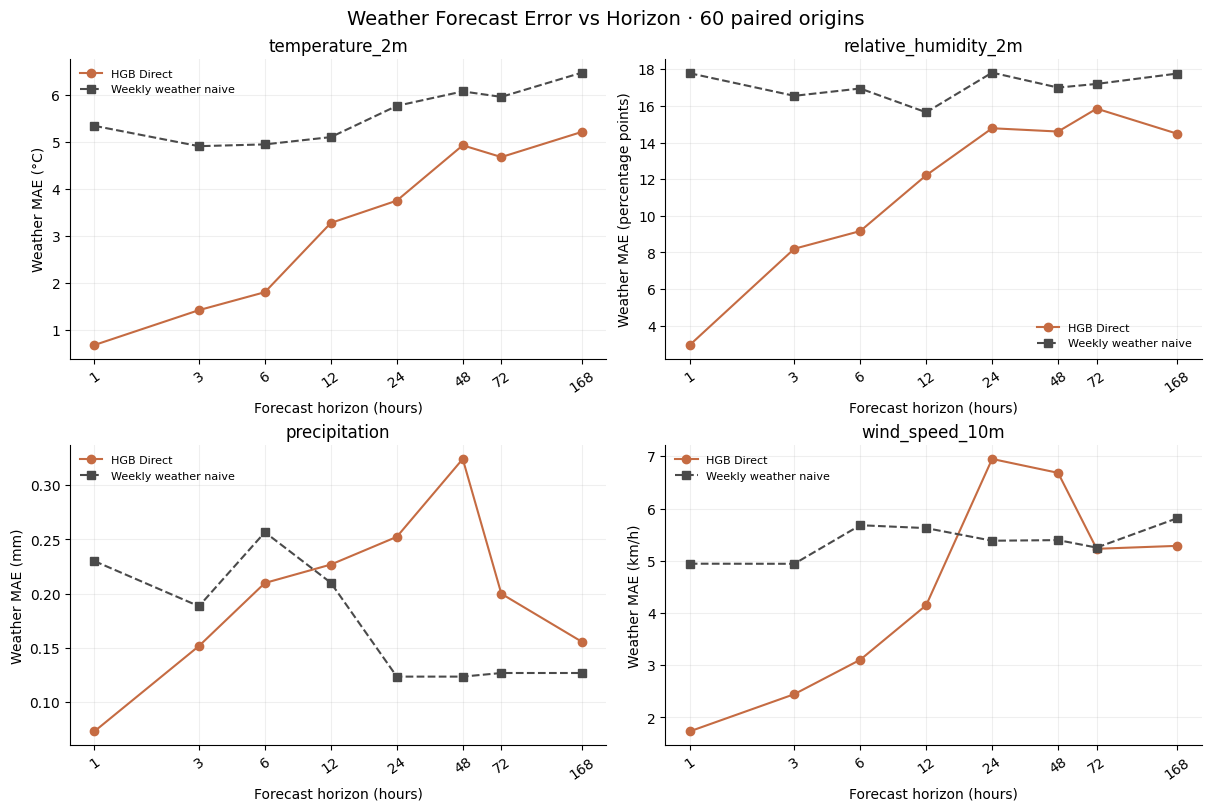

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, variable in zip(axes.flat, WEATHER_COLUMNS):
    subset = weather_metrics.loc[weather_metrics["Variable"].eq(variable)]
    ax.plot(subset["Horizon"], subset["HGB MAE"], marker="o", color="#C56B42", label="HGB Direct")
    ax.plot(subset["Horizon"], subset["Seasonal Naive MAE"], marker="s", linestyle="--", color="#4A4A4A", label="Weekly weather naive")
    ax.set_title(variable)
    ax.set_xlabel("Forecast horizon (hours)")
    ax.set_ylabel(f"Weather MAE ({WEATHER_UNITS[variable]})")
    ax.set_xscale("log", base=2)
    ax.set_xticks(HORIZONS, labels=[str(h) for h in HORIZONS])
    ax.tick_params(axis="x", rotation=35)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Weather Forecast Error vs Horizon · 60 paired origins", fontsize=14)
plt.show()

## Forecasted Weather training features · 用历史上可实现的天气预测训练需求模型

直接拿已经见过训练标签的天气模型在同一行生成“预测天气”，会让需求训练特征过于理想。这里采用时间顺序回测：4 月前以 168h 天气季节朴素预测 warm-up；4–6 月、7–8 月、9 月至测试前分别用在区间开始前完成训练的天气 HGB 预测。每个训练样本的天气特征都来自当时可用的天气模型，且每个需求 horizon 的训练行数仍与 09 完全一致。

In [9]:
OOF_CUTOFFS = (
    pd.Timestamp("2024-04-01 00:00"),
    pd.Timestamp("2024-07-01 00:00"),
    pd.Timestamp("2024-09-01 00:00"),
)
oof_weather_by_horizon = {}
oof_source_rows = []
for horizon in HORIZONS:
    train_first, train_target = training_specs[horizon]
    # Warm-up uses only weather from target−168h, which is ≤ each origin for h≤168.
    oof_values = weather_seasonal_naive(train_first, train_target).to_numpy(copy=True)
    sources = np.full(len(train_first), "Weekly seasonal warm-up", dtype=object)
    for fold_start, fold_end in zip(OOF_CUTOFFS, (*OOF_CUTOFFS[1:], fixed_test_start)):
        prediction_mask = (train_first >= fold_start) & (train_first < fold_end)
        fit_mask = train_target < fold_start
        if not prediction_mask.any():
            continue
        assert fit_mask.any()
        assert (train_target[fit_mask] < fold_start).all()
        assert (train_first[prediction_mask] >= fold_start).all()
        fit_matrix = make_weather_matrix(train_first[fit_mask], train_target[fit_mask])
        forecast_matrix = make_weather_matrix(
            train_first[prediction_mask], train_target[prediction_mask]
        )
        for variable_index, variable in enumerate(WEATHER_COLUMNS):
            model = HistGradientBoostingRegressor(**WEATHER_MODEL_PARAMETERS)
            model.fit(fit_matrix, weather_target.loc[train_target[fit_mask], variable].to_numpy())
            oof_values[prediction_mask, variable_index] = model.predict(forecast_matrix)
        sources[prediction_mask] = f"HGB trained before {fold_start.date()}"
        oof_source_rows.append({
            "Horizon": horizon, "Fold starts": fold_start, "Fold ends": fold_end,
            "Weather fit labels": int(fit_mask.sum()), "Demand rows predicted": int(prediction_mask.sum()),
            "Training labels < fold start": "PASS",
        })
    assert np.isfinite(oof_values).all()
    assert (train_first[sources == "Weekly seasonal warm-up"] < OOF_CUTOFFS[0]).all()
    oof_weather_by_horizon[horizon] = pd.DataFrame(oof_values, columns=PREDICTED_WEATHER_COLUMNS)
    print(f"OOF weather ready: h={horizon:>3}h; {len(train_first):,} demand training pairs")

oof_source_table = pd.DataFrame(oof_source_rows)
display(oof_source_table)

OOF weather ready: h=  1h; 6,857 demand training pairs


OOF weather ready: h=  3h; 6,854 demand training pairs


OOF weather ready: h=  6h; 6,851 demand training pairs


OOF weather ready: h= 12h; 6,845 demand training pairs


OOF weather ready: h= 24h; 6,833 demand training pairs


OOF weather ready: h= 48h; 6,809 demand training pairs


OOF weather ready: h= 72h; 6,785 demand training pairs


OOF weather ready: h=168h; 6,689 demand training pairs


,Horizon,Fold starts,Fold ends,Weather fit labels,Demand rows predicted,Training labels < fold start
0,1,2024-04-01,2024-07-01 00:00:00,2015,2184,PASS
1,1,2024-07-01,2024-09-01 00:00:00,4199,1488,PASS
2,1,2024-09-01,2024-10-19 18:00:00,5687,1170,PASS
3,3,2024-04-01,2024-07-01 00:00:00,2012,2184,PASS
4,3,2024-07-01,2024-09-01 00:00:00,4196,1488,PASS
5,3,2024-09-01,2024-10-19 18:00:00,5684,1168,PASS
6,6,2024-04-01,2024-07-01 00:00:00,2009,2184,PASS
7,6,2024-07-01,2024-09-01 00:00:00,4193,1488,PASS
8,6,2024-09-01,2024-10-19 18:00:00,5681,1165,PASS
9,12,2024-04-01,2024-07-01 00:00:00,2003,2184,PASS


## Three demand scenarios · 相同样本、相同 HGB 设置

Forecasted Weather 训练矩阵只含 `*_pred` 天气列；测试矩阵的这些列只从固定测试起点以前拟合的天气模型输出取得。Oracle 与 No Future Weather 分别保留 09 的训练特征和参数，便于逐点复核旧结果。

In [10]:
SCENARIO_LABELS = {
    "oracle": "Oracle", "forecasted": "Forecasted Weather", "no_weather": "No Future Weather"
}
SCENARIO_FEATURES = {
    "oracle": calendar_columns + list(WEATHER_COLUMNS) + DEMAND_COLUMNS,
    "forecasted": calendar_columns + PREDICTED_WEATHER_COLUMNS + DEMAND_COLUMNS,
    "no_weather": calendar_columns + DEMAND_COLUMNS,
}

def make_demand_matrix(scenario, first_future_times, target_times, predicted_weather=None):
    first_future_times = pd.DatetimeIndex(first_future_times)
    target_times = pd.DatetimeIndex(target_times)
    assert len(first_future_times) == len(target_times)
    calendar_part = calendar_target.loc[target_times].reset_index(drop=True)
    history_part = origin_demand.loc[first_future_times, DEMAND_COLUMNS].reset_index(drop=True)
    pieces = [calendar_part]
    if scenario == "oracle":
        pieces.append(weather_target.loc[target_times, list(WEATHER_COLUMNS)].reset_index(drop=True))
    elif scenario == "forecasted":
        assert predicted_weather is not None
        assert list(predicted_weather.columns) == PREDICTED_WEATHER_COLUMNS
        assert len(predicted_weather) == len(first_future_times)
        pieces.append(predicted_weather.reset_index(drop=True))
    elif scenario != "no_weather":
        raise ValueError(scenario)
    pieces.append(history_part)
    matrix = pd.concat(pieces, axis=1)[SCENARIO_FEATURES[scenario]]
    assert matrix.notna().all(axis=None) and np.isfinite(matrix.to_numpy()).all()
    if scenario == "forecasted":
        assert set(matrix.columns).isdisjoint(WEATHER_COLUMNS)
    return matrix

demand_models = {scenario: {} for scenario in SCENARIO_LABELS}
for scenario in SCENARIO_LABELS:
    for horizon in HORIZONS:
        train_first, train_target = training_specs[horizon]
        predicted_weather = oof_weather_by_horizon[horizon] if scenario == "forecasted" else None
        matrix = make_demand_matrix(scenario, train_first, train_target, predicted_weather)
        label = observed_demand.reindex(train_target).to_numpy()
        fitted = HistGradientBoostingRegressor(**DEMAND_MODEL_PARAMETERS)
        fitted.fit(matrix, label)
        demand_models[scenario][horizon] = fitted
    print(f"Demand HGB trained: {SCENARIO_LABELS[scenario]}, {len(HORIZONS)} horizons")
assert all(len(models) == 8 for models in demand_models.values())

Demand HGB trained: Oracle, 8 horizons


Demand HGB trained: Forecasted Weather, 8 horizons


Demand HGB trained: No Future Weather, 8 horizons


## Recursive path · 先逐小时预测天气，再回填需求预测

天气路径在 8 个已报告的终点使用对应 Direct weather HGB，其余中间小时由 h=1 weather HGB 递归生成。所有天气 lag/rolling 如果位于起报时刻之后，就从本条轨迹已预测天气读取。需求 lag/rolling 同理只读取起报前真实需求或本条轨迹的需求预测；两种误差传播分别存在。

In [11]:
def predict_weather_path(first_future_times, horizon):
    starts = pd.DatetimeIndex(first_future_times)
    origins = starts - pd.Timedelta(hours=1)
    prediction = np.full((len(starts), horizon, len(WEATHER_COLUMNS)), np.nan)
    direct_anchors = {
        lead: predict_weather_direct(
            starts, starts + pd.Timedelta(hours=lead - 1), lead
        ).to_numpy()
        for lead in HORIZONS if lead <= horizon
    }

    def prior_weather_values(variable, variable_index, target_times, step, lag):
        if step <= lag:
            source_times = target_times - pd.Timedelta(hours=lag)
            assert (source_times <= origins).all()
            return observed_weather[variable].reindex(source_times).to_numpy()
        return prediction[:, step - lag - 1, variable_index]

    for step in range(1, horizon + 1):
        if step in direct_anchors:
            prediction[:, step - 1, :] = direct_anchors[step]
            continue
        target_times = starts + pd.Timedelta(hours=step - 1)
        row = weather_calendar.loc[target_times].reset_index(drop=True).copy()
        for variable_index, variable in enumerate(WEATHER_COLUMNS):
            for lag in WEATHER_LAGS:
                row[f"{variable}_lag_{lag}"] = prior_weather_values(
                    variable, variable_index, target_times, step, lag
                )
            for window in WEATHER_ROLLING_WINDOWS:
                prior = np.column_stack([
                    prior_weather_values(variable, variable_index, target_times, step, lag)
                    for lag in range(1, window + 1)
                ])
                row[f"{variable}_roll_mean_{window}"] = prior.mean(axis=1)
                row[f"{variable}_roll_std_{window}"] = prior.std(axis=1, ddof=0)
        matrix = row[WEATHER_INPUT_COLUMNS]
        assert matrix.notna().all(axis=None)
        prediction[:, step - 1, :] = np.column_stack([
            weather_models[1][variable].predict(matrix) for variable in WEATHER_COLUMNS
        ])
    assert np.isfinite(prediction).all()
    for lead, anchor in direct_anchors.items():
        assert np.allclose(prediction[:, lead - 1, :], anchor)
    return prediction

def recursive_demand_predict(first_future_times, horizon, scenario, weather_path=None, history=observed_demand):
    starts = pd.DatetimeIndex(first_future_times)
    origins = starts - pd.Timedelta(hours=1)
    prediction = np.full((len(starts), horizon), np.nan)
    if scenario == "forecasted":
        assert weather_path is not None
        assert weather_path.shape == (len(starts), horizon, len(WEATHER_COLUMNS))
    for step in range(1, horizon + 1):
        target_times = starts + pd.Timedelta(hours=step - 1)
        row = calendar_target.loc[target_times].reset_index(drop=True).copy()
        if scenario == "oracle":
            row[list(WEATHER_COLUMNS)] = weather_target.loc[
                target_times, list(WEATHER_COLUMNS)
            ].reset_index(drop=True)
        elif scenario == "forecasted":
            row[PREDICTED_WEATHER_COLUMNS] = weather_path[:, step - 1, :]
        for lag in (1, 24, 168):
            if step <= lag:
                source_times = target_times - pd.Timedelta(hours=lag)
                assert (source_times <= origins).all()
                values = history.reindex(source_times).to_numpy()
            else:
                values = prediction[:, step - lag - 1]
            row[f"lag_{lag}"] = values
        for window in (3, 6):
            components = []
            for back in range(1, window + 1):
                if step <= back:
                    source_times = target_times - pd.Timedelta(hours=back)
                    assert (source_times <= origins).all()
                    components.append(history.reindex(source_times).to_numpy())
                else:
                    components.append(prediction[:, step - back - 1])
            row[f"rolling_mean_{window}"] = np.mean(np.column_stack(components), axis=1)
        matrix = row[SCENARIO_FEATURES[scenario]]
        assert matrix.notna().all(axis=None)
        prediction[:, step - 1] = demand_models[scenario][1].predict(matrix)
    assert np.isfinite(prediction).all()
    return prediction

## Downstream Leakage Audit · `*_pred` 的唯一来源是天气模型

以下反事实检查把某一个起报点之后的真实需求改动一百万次，Forecasted Recursive 轨迹必须不变。对于天气，测试需求矩阵中的每个 `*_pred` 都与天气模型输出逐值一致，且不含目标时刻真实天气列。Oracle 读取真实天气是其定义；Forecasted Weather 的真实天气只用于独立评分。

In [12]:
sample_first = first_future_origins[0]
sample_target = sample_first + pd.Timedelta(hours=71)
sample_weather = predict_weather_direct([sample_first], [sample_target], 72)
forecasted_demand_matrix = make_demand_matrix(
    "forecasted", [sample_first], [sample_target], sample_weather
)
assert np.array_equal(
    forecasted_demand_matrix[PREDICTED_WEATHER_COLUMNS].to_numpy(),
    sample_weather.to_numpy(),
)
assert set(forecasted_demand_matrix.columns).isdisjoint(WEATHER_COLUMNS)
sample_path = predict_weather_path([sample_first], 24)
future_corrupted_history = observed_demand.copy()
future_corrupted_history.loc[future_corrupted_history.index >= sample_first] += 1_000_000
normal_recursive = recursive_demand_predict([sample_first], 24, "forecasted", sample_path)
corrupted_recursive = recursive_demand_predict(
    [sample_first], 24, "forecasted", sample_path, future_corrupted_history
)
assert np.array_equal(normal_recursive, corrupted_recursive)
downstream_audit = pd.DataFrame([
    {"Check": "Future weather leakage", "Result": "PASS"},
    {"Check": "Rolling target contamination", "Result": "PASS"},
    {"Check": "Train/test chronology", "Result": "PASS"},
    {"Check": "Forecasted-weather source = weather model", "Result": "PASS"},
    {"Check": "Future actual demand excluded from recursion", "Result": "PASS"},
])
display(downstream_audit)

,Check,Result
0,Future weather leakage,PASS
1,Rolling target contamination,PASS
2,Train/test chronology,PASS
3,Forecasted-weather source = weather model,PASS
4,Future actual demand excluded from recursion,PASS


## Main test panel · 60 个起点 × 8 个 horizon

需求预测的六条 HGB 曲线和 Weekly Seasonal Naive 都使用相同的 `ride_count(t+h)`。Weekly Naive 的来源是 `t+h−168h`，在全部所选 horizon 下均不晚于起报时刻。Forecasted Direct 与 Forecasted Recursive 在每个评分终点使用同一份天气预测，便于比较两种需求策略。

In [13]:
forecasted_weather_features = weather_main_panel[
    ["Horizon", "First Future Hour", "Target Timestamp"] + PREDICTED_WEATHER_COLUMNS
].copy()
assert set(forecasted_weather_features.columns).isdisjoint(WEATHER_COLUMNS)
assert not forecasted_weather_features.duplicated(
    ["Horizon", "First Future Hour", "Target Timestamp"]
).any()

weather_path_main = predict_weather_path(first_future_origins, 168)
recursive_main = {
    scenario: recursive_demand_predict(
        first_future_origins, 168, scenario,
        weather_path_main if scenario == "forecasted" else None,
    )
    for scenario in SCENARIO_LABELS
}

main_parts = []
for horizon in HORIZONS:
    first_future = first_future_origins
    target_times = first_future + pd.Timedelta(hours=horizon - 1)
    actual = observed_demand.reindex(target_times).to_numpy()
    weekly_source = target_times - pd.Timedelta(hours=168)
    assert (weekly_source <= first_future - pd.Timedelta(hours=1)).all()
    weekly = observed_demand.reindex(weekly_source).to_numpy()
    predicted_weather = forecasted_weather_features.loc[
        forecasted_weather_features["Horizon"].eq(horizon), PREDICTED_WEATHER_COLUMNS
    ].reset_index(drop=True)
    assert np.allclose(predicted_weather.to_numpy(), weather_path_main[:, horizon - 1, :])
    row = {
        "Horizon": horizon, "First Future Hour": first_future,
        "Forecast Origin": first_future - pd.Timedelta(hours=1),
        "Target Timestamp": target_times, "Actual": actual, "Weekly Naive": weekly,
    }
    for scenario, label in SCENARIO_LABELS.items():
        row[f"Recursive {label}"] = recursive_main[scenario][:, horizon - 1]
        matrix = make_demand_matrix(
            scenario, first_future, target_times,
            predicted_weather if scenario == "forecasted" else None,
        )
        row[f"Direct {label}"] = demand_models[scenario][horizon].predict(matrix)
    main_parts.append(pd.DataFrame(row))
main_panel = pd.concat(main_parts, ignore_index=True)
prediction_columns = [
    f"{strategy} {label}"
    for strategy in ("Recursive", "Direct")
    for label in SCENARIO_LABELS.values()
] + ["Weekly Naive"]
assert len(main_panel) == 60 * len(HORIZONS)
assert main_panel.groupby("Horizon").size().eq(60).all()
assert not main_panel.duplicated(["Horizon", "First Future Hour", "Target Timestamp"]).any()
assert np.isfinite(main_panel[["Actual"] + prediction_columns].to_numpy()).all()
assert np.allclose(
    main_panel.loc[main_panel["Horizon"].eq(1), "Recursive Forecasted Weather"],
    main_panel.loc[main_panel["Horizon"].eq(1), "Direct Forecasted Weather"],
)
display(main_panel.head(4))

,Horizon,First Future Hour,Forecast Origin,Target Timestamp,Actual,Weekly Naive,Recursive Oracle,Direct Oracle,Recursive Forecasted Weather,Direct Forecasted Weather,Recursive No Future Weather,Direct No Future Weather
0,1,2024-10-19 18:00:00,2024-10-19 17:00:00,2024-10-19 18:00:00,11471,11670,11571.081670,11571.081670,11737.353638,11737.353638,11737.436627,11737.436627
1,1,2024-10-20 18:00:00,2024-10-20 17:00:00,2024-10-20 18:00:00,11216,11268,11692.532083,11692.532083,11913.266441,11913.266441,11529.051458,11529.051458
2,1,2024-10-21 18:00:00,2024-10-21 17:00:00,2024-10-21 18:00:00,16159,11031,15348.168651,15348.168651,15250.184072,15250.184072,15423.654042,15423.654042
3,1,2024-10-22 18:00:00,2024-10-22 17:00:00,2024-10-22 18:00:00,17637,14790,16589.941963,16589.941963,16621.321748,16621.321748,16489.097546,16489.097546


## Three-scenario benchmark · 先复核 09，再比较 Forecasted Weather

Oracle 与 No Future Weather 两套需求模型使用 09 的原始训练矩阵、同一超参数和 60 个目标点。下方断言其 MAE 与 09 已保存结果在四舍五入误差内一致；任何不一致都会停止 Notebook，而不是继续解释错误对比。

In [14]:
metric_rows = []
for horizon, frame in main_panel.groupby("Horizon", sort=True):
    for method in prediction_columns:
        metric_rows.append({
            "Horizon": horizon, "Method": method, "Points": len(frame),
            **score_predictions(frame["Actual"], frame[method]),
        })
metric_table = pd.DataFrame(metric_rows)
assert metric_table["Points"].eq(60).all()

reference_09 = {
    "Recursive Oracle": [684.98, 617.91, 494.05, 172.69, 1574.94, 1584.57, 1664.98, 1696.67],
    "Recursive No Future Weather": [715.25, 592.36, 449.28, 216.79, 2659.13, 3392.51, 3780.44, 4062.98],
    "Direct Oracle": [684.98, 669.45, 574.55, 273.26, 1307.71, 1499.27, 1679.43, 1923.54],
    "Direct No Future Weather": [715.25, 925.32, 500.71, 374.71, 2128.37, 2630.58, 2877.65, 2930.74],
    "Weekly Naive": [2238.73, 1257.72, 627.13, 195.85, 2810.15, 2914.83, 2862.25, 2733.23],
}
reference_rows = []
for method, expected in reference_09.items():
    measured = metric_table.loc[metric_table["Method"].eq(method), "MAE"].to_numpy()
    maximum_delta = np.max(np.abs(measured - expected))
    assert maximum_delta < 0.15, (method, maximum_delta)
    reference_rows.append({"09 method": method, "Max |MAE difference|": maximum_delta, "Result": "PASS"})
display(pd.DataFrame(reference_rows).round(3))

benchmark_rows = []
for horizon in HORIZONS:
    lookup = metric_table.loc[metric_table["Horizon"].eq(horizon)].set_index("Method")
    for strategy in ("Direct", "Recursive"):
        benchmark_rows.append({
            "Horizon": horizon, "Model": strategy,
            "Oracle MAE": lookup.loc[f"{strategy} Oracle", "MAE"],
            "Forecasted Weather MAE": lookup.loc[f"{strategy} Forecasted Weather", "MAE"],
            "No-weather MAE": lookup.loc[f"{strategy} No Future Weather", "MAE"],
            "Weekly Naive MAE": lookup.loc["Weekly Naive", "MAE"],
            "Forecasted RMSE": lookup.loc[f"{strategy} Forecasted Weather", "RMSE"],
            "Forecasted Mean Error": lookup.loc[f"{strategy} Forecasted Weather", "Mean Error"],
        })
benchmark = pd.DataFrame(benchmark_rows)
display(benchmark.round(2))

,09 method,Max |MAE difference|,Result
0,Recursive Oracle,0.004,PASS
1,Recursive No Future Weather,0.005,PASS
2,Direct Oracle,0.005,PASS
3,Direct No Future Weather,0.005,PASS
4,Weekly Naive,0.003,PASS


,Horizon,Model,Oracle MAE,Forecasted Weather MAE,No-weather MAE,Weekly Naive MAE,Forecasted RMSE,Forecasted Mean Error
0,1,Direct,684.98,722.62,715.25,2238.73,1128.43,-270.96
1,1,Recursive,684.98,722.62,715.25,2238.73,1128.43,-270.96
2,3,Direct,669.45,737.53,925.32,1257.72,943.29,-73.37
3,3,Recursive,617.91,637.32,592.36,1257.72,877.53,-55.91
4,6,Direct,574.55,507.82,500.71,627.13,658.84,139.97
5,6,Recursive,494.05,561.18,449.28,627.13,715.84,-223.13
6,12,Direct,273.26,386.19,374.71,195.85,510.78,-30.51
7,12,Recursive,172.69,211.53,216.79,195.85,278.77,-86.64
8,24,Direct,1307.71,2256.93,2128.37,2810.15,3032.28,-1255.54
9,24,Recursive,1574.94,2489.24,2659.13,2810.15,3266.74,-397.77


### Oracle Gap Recovery · 允许负值，不截断

`Oracle Gap = No-weather MAE − Oracle MAE`；`Recovered MAE = No-weather MAE − Forecasted Weather MAE`；`Recovery Ratio = Recovered MAE / Oracle Gap`。若 Forecasted Weather 更差，Recovered MAE 为负。若 Oracle Gap 本身为负，比例的“恢复”直觉失效，仍保留带符号原值并在解释时单独标注。只有分母恰好为零时比例记为缺失。

In [15]:
recovery_table = benchmark[[
    "Horizon", "Model", "Oracle MAE", "Forecasted Weather MAE", "No-weather MAE"
]].copy()
recovery_table["Oracle Gap"] = recovery_table["No-weather MAE"] - recovery_table["Oracle MAE"]
recovery_table["Recovered MAE"] = recovery_table["No-weather MAE"] - recovery_table["Forecasted Weather MAE"]
recovery_table["Recovery Ratio"] = np.where(
    np.isclose(recovery_table["Oracle Gap"], 0),
    np.nan,
    recovery_table["Recovered MAE"] / recovery_table["Oracle Gap"],
)
recovery_table["Recovery Ratio %"] = 100 * recovery_table["Recovery Ratio"]
display(recovery_table[[
    "Horizon", "Model", "Oracle Gap", "Recovered MAE", "Recovery Ratio %"
]].round(2))

ranking_rows = []
for horizon in HORIZONS:
    pair = benchmark.loc[benchmark["Horizon"].eq(horizon)].set_index("Model")
    row = {"Horizon": horizon}
    for scenario_column, label in (
        ("Oracle MAE", "Oracle"), ("Forecasted Weather MAE", "Forecasted"),
        ("No-weather MAE", "No-weather")
    ):
        direct, recursive = pair.loc["Direct", scenario_column], pair.loc["Recursive", scenario_column]
        row[f"{label} winner"] = "Tie" if np.isclose(direct, recursive) else (
            "Direct" if direct < recursive else "Recursive"
        )
    row["Forecasted Direct beats Weekly"] = (
        pair.loc["Direct", "Forecasted Weather MAE"] < pair.loc["Direct", "Weekly Naive MAE"]
    )
    row["Forecasted Recursive beats Weekly"] = (
        pair.loc["Recursive", "Forecasted Weather MAE"] < pair.loc["Recursive", "Weekly Naive MAE"]
    )
    ranking_rows.append(row)
ranking_table = pd.DataFrame(ranking_rows)
display(ranking_table)

,Horizon,Model,Oracle Gap,Recovered MAE,Recovery Ratio %
0,1,Direct,30.27,-7.37,-24.34
1,1,Recursive,30.27,-7.37,-24.34
2,3,Direct,255.86,187.79,73.40
3,3,Recursive,-25.56,-44.96,175.92
4,6,Direct,-73.84,-7.11,9.63
5,6,Recursive,-44.77,-111.90,249.94
6,12,Direct,101.45,-11.49,-11.32
7,12,Recursive,44.10,5.25,11.91
8,24,Direct,820.66,-128.56,-15.67
9,24,Recursive,1084.19,169.89,15.67


,Horizon,Oracle winner,Forecasted winner,No-weather winner,Forecasted Direct beats Weekly,Forecasted Recursive beats Weekly
0,1,Tie,Tie,Tie,True,True
1,3,Recursive,Recursive,Recursive,True,True
2,6,Recursive,Direct,Recursive,True,True
3,12,Recursive,Recursive,Recursive,False,False
4,24,Direct,Direct,Direct,True,True
5,48,Direct,Direct,Direct,True,False
6,72,Recursive,Direct,Direct,False,False
7,168,Recursive,Direct,Direct,False,False


### Figure 2 · Demand MAE vs Forecast Horizon

Direct 与 Recursive 分面展示，每个面板都显示三种天气场景和同一 Weekly Naive。h=1、3、6、12 的目标时钟点因固定每日起点而不同，所以跨 horizon 的 MAE 曲线还包含目标时段难度变化，不能把每次升降都解释为纯粹的 lead-time 效应。

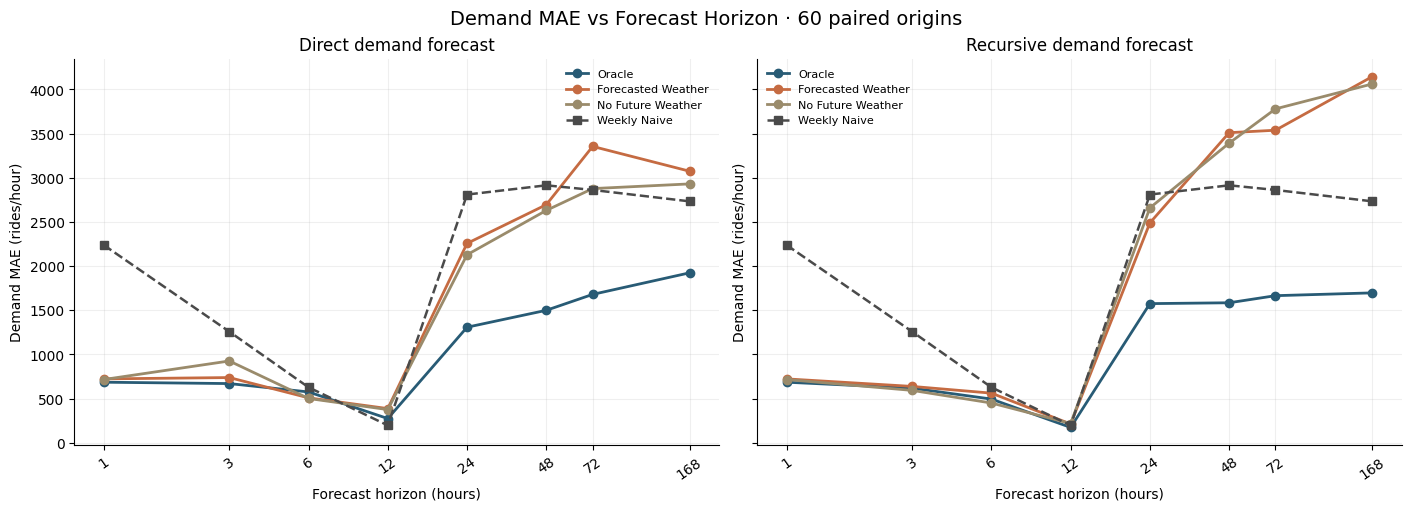

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, constrained_layout=True)
for ax, strategy in zip(axes, ("Direct", "Recursive")):
    for label in ("Oracle", "Forecasted Weather", "No Future Weather"):
        series = metric_table.loc[metric_table["Method"].eq(f"{strategy} {label}")]
        ax.plot(
            series["Horizon"], series["MAE"], marker="o", linewidth=2,
            label=label, color=PALETTE[label],
        )
    weekly = metric_table.loc[metric_table["Method"].eq("Weekly Naive")]
    ax.plot(weekly["Horizon"], weekly["MAE"], marker="s", linestyle="--",
            linewidth=1.8, color=PALETTE["Weekly Naive"], label="Weekly Naive")
    ax.set_title(f"{strategy} demand forecast")
    ax.set_xlabel("Forecast horizon (hours)")
    ax.set_ylabel("Demand MAE (rides/hour)")
    ax.set_xscale("log", base=2)
    ax.set_xticks(HORIZONS, labels=[str(h) for h in HORIZONS])
    ax.tick_params(axis="x", rotation=35)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Demand MAE vs Forecast Horizon · 60 paired origins", fontsize=14)
plt.show()

### Figure 3 · Oracle Gap Recovery Ratio vs Horizon

零线代表预测天气没有优于 No Future Weather；100% 代表达到 Oracle MAE。对于 Oracle Gap 为负的 horizon，请直接结合上表的带符号 Gap 和 Recovered MAE 阅读，不把高比例当成“恢复优势”。

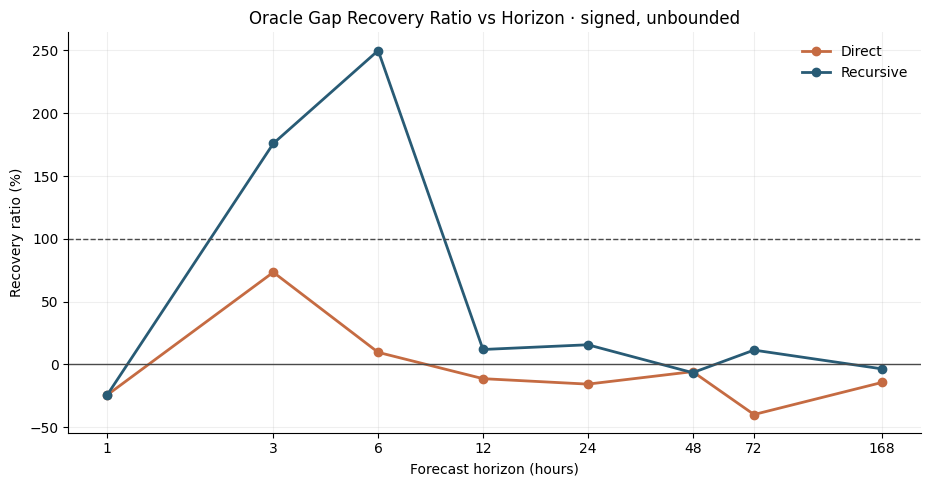

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.2))
for strategy in ("Direct", "Recursive"):
    subset = recovery_table.loc[recovery_table["Model"].eq(strategy)]
    ax.plot(subset["Horizon"], subset["Recovery Ratio %"], marker="o", linewidth=2,
            color=PALETTE[strategy], label=strategy)
ax.axhline(0, color="#4A4A4A", linewidth=1)
ax.axhline(100, color="#4A4A4A", linewidth=1, linestyle="--")
ax.set_title("Oracle Gap Recovery Ratio vs Horizon · signed, unbounded")
ax.set_xlabel("Forecast horizon (hours)")
ax.set_ylabel("Recovery ratio (%)")
ax.set_xscale("log", base=2)
ax.set_xticks(HORIZONS, labels=[str(h) for h in HORIZONS])
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()

## Error Propagation · 天气误差与需求误差的配对关系

对每个相同目标点计算 `|weather_actual − weather_pred|` 和 `|demand_actual − demand_pred|`，分别汇总 Pearson 与 Spearman 相关。温度以及其余三个连续天气变量均纳入；同时区分 Direct 和 Recursive。**Correlation ≠ Causation**：天气条件、小时难度和季节可同时影响两种误差，相关系数不能证明天气误差导致了多少需求误差。

In [18]:
paired_error_panel = main_panel.merge(
    weather_main_panel,
    on=["Horizon", "First Future Hour", "Target Timestamp"],
    validate="one_to_one",
)
assert len(paired_error_panel) == len(main_panel)

def safe_correlations(first, second):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    if np.std(first) == 0 or np.std(second) == 0:
        return np.nan, np.nan
    return pearsonr(first, second).statistic, spearmanr(first, second).statistic

correlation_rows = []
for horizon, frame in paired_error_panel.groupby("Horizon", sort=True):
    for variable in WEATHER_COLUMNS:
        weather_error = np.abs(frame[f"{variable}_actual"] - frame[f"{variable}_pred"])
        for strategy in ("Direct", "Recursive"):
            demand_error = np.abs(frame["Actual"] - frame[f"{strategy} Forecasted Weather"])
            pearson_r, spearman_r = safe_correlations(weather_error, demand_error)
            correlation_rows.append({
                "Horizon": horizon, "Weather Variable": variable, "Demand Model": strategy,
                "Pearson r": pearson_r, "Spearman r": spearman_r, "Points": len(frame),
            })
correlation_table = pd.DataFrame(correlation_rows)
for strategy in ("Direct", "Recursive"):
    print(f"{strategy} · all 8 horizons × 4 weather variables")
    display(correlation_table.loc[
        correlation_table["Demand Model"].eq(strategy)
    ].round(3).reset_index(drop=True))

Direct · all 8 horizons × 4 weather variables


,Horizon,Weather Variable,Demand Model,Pearson r,Spearman r,Points
0,1,temperature_2m,Direct,0.012,0.117,60
1,1,relative_humidity_2m,Direct,0.033,0.143,60
2,1,precipitation,Direct,0.109,0.033,60
3,1,wind_speed_10m,Direct,0.131,0.044,60
4,3,temperature_2m,Direct,0.025,0.061,60
5,3,relative_humidity_2m,Direct,-0.175,-0.140,60
6,3,precipitation,Direct,0.387,0.361,60
7,3,wind_speed_10m,Direct,0.025,0.064,60
8,6,temperature_2m,Direct,0.375,0.277,60
9,6,relative_humidity_2m,Direct,-0.057,-0.063,60


Recursive · all 8 horizons × 4 weather variables


,Horizon,Weather Variable,Demand Model,Pearson r,Spearman r,Points
0,1,temperature_2m,Recursive,0.012,0.117,60
1,1,relative_humidity_2m,Recursive,0.033,0.143,60
2,1,precipitation,Recursive,0.109,0.033,60
3,1,wind_speed_10m,Recursive,0.131,0.044,60
4,3,temperature_2m,Recursive,-0.160,-0.205,60
5,3,relative_humidity_2m,Recursive,-0.096,-0.070,60
6,3,precipitation,Recursive,0.327,0.355,60
7,3,wind_speed_10m,Recursive,0.018,0.085,60
8,6,temperature_2m,Recursive,0.168,-0.053,60
9,6,relative_humidity_2m,Recursive,-0.215,-0.219,60


### Figure 4 · Temperature Error vs Demand Error

三个 horizon 各有 60 个成对目标点；纵轴为 Direct Forecasted Weather 的绝对需求误差，横轴为温度预测的绝对误差。点云与相关系数仅描述关联，不能单凭这张图推断因果。

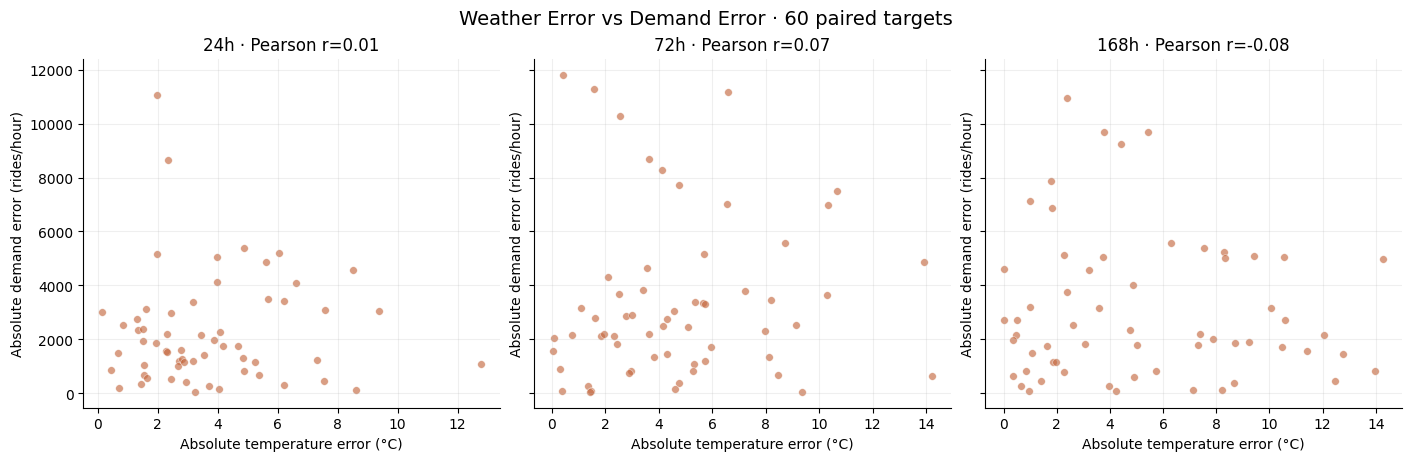

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=True)
for ax, horizon in zip(axes, FOCUS_HORIZONS):
    frame = paired_error_panel.loc[paired_error_panel["Horizon"].eq(horizon)]
    x = np.abs(frame["temperature_2m_actual"] - frame["temperature_2m_pred"])
    y = np.abs(frame["Actual"] - frame["Direct Forecasted Weather"])
    correlation = correlation_table.loc[
        correlation_table["Horizon"].eq(horizon)
        & correlation_table["Weather Variable"].eq("temperature_2m")
        & correlation_table["Demand Model"].eq("Direct"), "Pearson r"
    ].iloc[0]
    ax.scatter(x, y, color="#C56B42", alpha=0.65, s=30, edgecolor="white", linewidth=0.4)
    ax.set_title(f"{horizon}h · Pearson r={correlation:.2f}")
    ax.set_xlabel("Absolute temperature error (°C)")
    ax.set_ylabel("Absolute demand error (rides/hour)")
    ax.grid(alpha=0.2)
fig.suptitle("Weather Error vs Demand Error · 60 paired targets", fontsize=14)
plt.show()

## Robustness · 672 个完全相同的目标小时

60 个主起点在不同 horizon 对应不同目标时钟点。为了减少这一组成差异，固定 2024-11-18 至 2024-12-15 的 672 个目标小时，再分别向前推 24、72、168 小时起报。天气模型、需求模型和参数完全不变；Weekly Naive 也在同一批目标点评分。这里更适合判断长 horizon 的相对排名是否稳健。

In [20]:
common_panels = {}
common_weather_pred = {}
common_metric_rows = []
for horizon in FOCUS_HORIZONS:
    target_times = common_target_times
    first_future = target_times - pd.Timedelta(hours=horizon - 1)
    assert (first_future >= fixed_test_start).all()
    weather_path = predict_weather_path(first_future, horizon)
    predicted_weather = predict_weather_direct(first_future, target_times, horizon)
    assert np.allclose(weather_path[:, -1, :], predicted_weather.to_numpy())
    common_weather_pred[horizon] = predicted_weather
    weekly_source = target_times - pd.Timedelta(hours=168)
    assert (weekly_source <= first_future - pd.Timedelta(hours=1)).all()
    frame = pd.DataFrame({
        "Horizon": horizon, "First Future Hour": first_future,
        "Target Timestamp": target_times,
        "Actual": observed_demand.reindex(target_times).to_numpy(),
        "Weekly Naive": observed_demand.reindex(weekly_source).to_numpy(),
    })
    for scenario, label in SCENARIO_LABELS.items():
        matrix = make_demand_matrix(
            scenario, first_future, target_times,
            predicted_weather if scenario == "forecasted" else None,
        )
        frame[f"Direct {label}"] = demand_models[scenario][horizon].predict(matrix)
        frame[f"Recursive {label}"] = recursive_demand_predict(
            first_future, horizon, scenario,
            weather_path if scenario == "forecasted" else None,
        )[:, -1]
    assert len(frame) == 672 and np.isfinite(frame[["Actual"] + prediction_columns].to_numpy()).all()
    common_panels[horizon] = frame
    for method in prediction_columns:
        common_metric_rows.append({
            "Horizon": horizon, "Method": method, "Common target points": len(frame),
            **score_predictions(frame["Actual"], frame[method]),
        })
    print(f"Common-target evaluation ready: h={horizon}h, targets={len(frame)}")

common_target_metrics = pd.DataFrame(common_metric_rows)
display(common_target_metrics[["Horizon", "Method", "Common target points", "MAE"]].round(2))

Common-target evaluation ready: h=24h, targets=672


Common-target evaluation ready: h=72h, targets=672


Common-target evaluation ready: h=168h, targets=672


,Horizon,Method,Common target points,MAE
0,24,Recursive Oracle,672,770.59
1,24,Recursive Forecasted Weather,672,1091.75
2,24,Recursive No Future Weather,672,1154.74
3,24,Direct Oracle,672,764.58
4,24,Direct Forecasted Weather,672,1053.19
5,24,Direct No Future Weather,672,1027.41
6,24,Weekly Naive,672,1323.70
7,72,Recursive Oracle,672,924.29
8,72,Recursive Forecasted Weather,672,1272.49
9,72,Recursive No Future Weather,672,1508.69


### 同一目标小时下的天气误差

下表单独检查 672 目标小时上的天气预测，避免把主样本不同目标小时的难度变化误认为天气误差随 lead time 变化。这里仍只用真实天气计算事后评分。

In [21]:
common_weather_rows = []
for horizon in FOCUS_HORIZONS:
    predicted = common_weather_pred[horizon]
    actual = weather_target.loc[common_target_times, list(WEATHER_COLUMNS)].reset_index(drop=True)
    for variable in WEATHER_COLUMNS:
        common_weather_rows.append({
            "Horizon": horizon, "Variable": variable, "Unit": WEATHER_UNITS[variable],
            "HGB MAE on 672 targets": mean_absolute_error(
                actual[variable], predicted[f"{variable}_pred"]
            ),
        })
common_weather_metrics = pd.DataFrame(common_weather_rows)
display(common_weather_metrics.round(3))

,Horizon,Variable,Unit,HGB MAE on 672 targets
0,24,temperature_2m,°C,2.767
1,24,relative_humidity_2m,percentage points,13.014
2,24,precipitation,mm,0.352
3,24,wind_speed_10m,km/h,5.096
4,72,temperature_2m,°C,3.930
5,72,relative_humidity_2m,percentage points,14.036
6,72,precipitation,mm,0.294
7,72,wind_speed_10m,km/h,5.175
8,168,temperature_2m,°C,4.150
9,168,relative_humidity_2m,percentage points,13.225


## Peak Hour Analysis · 工作日 07–09 与 16–19

在相同 672 目标小时中比较工作日早晚高峰、合并高峰和工作日非高峰。`Absolute improvement = No-weather MAE − Forecasted Weather MAE`；`% improvement` 除以同组 No-weather MAE。两者都报告，允许负值；Oracle MAE 同时列出作为理想边界。

In [22]:
peak_rows = []
for horizon, frame in common_panels.items():
    target = frame["Target Timestamp"]
    weekday = target.dt.dayofweek < 5
    morning = weekday & target.dt.hour.isin((7, 8, 9))
    evening = weekday & target.dt.hour.isin((16, 17, 18, 19))
    period_masks = {
        "Morning 07–09": morning,
        "Evening 16–19": evening,
        "Peak combined": morning | evening,
        "Weekday non-peak": weekday & ~(morning | evening),
    }
    expected_counts = {
        "Morning 07–09": 60, "Evening 16–19": 80,
        "Peak combined": 140, "Weekday non-peak": 340,
    }
    for period, mask in period_masks.items():
        subset = frame.loc[mask]
        assert len(subset) == expected_counts[period]
        for strategy in ("Direct", "Recursive"):
            oracle = mean_absolute_error(subset["Actual"], subset[f"{strategy} Oracle"])
            forecasted = mean_absolute_error(
                subset["Actual"], subset[f"{strategy} Forecasted Weather"]
            )
            no_weather = mean_absolute_error(
                subset["Actual"], subset[f"{strategy} No Future Weather"]
            )
            improvement = no_weather - forecasted
            peak_rows.append({
                "Horizon": horizon, "Period": period, "Model": strategy,
                "Paired targets": len(subset), "Oracle MAE": oracle,
                "Forecasted MAE": forecasted, "No-weather MAE": no_weather,
                "Absolute improvement": improvement,
                "Improvement %": 100 * improvement / no_weather,
            })
peak_table = pd.DataFrame(peak_rows)
display(peak_table.round(2))

,Horizon,Period,Model,Paired targets,Oracle MAE,Forecasted MAE,No-weather MAE,Absolute improvement,Improvement %
0,24,Morning 07–09,Direct,60,1474.88,1810.35,1812.54,2.19,0.12
1,24,Morning 07–09,Recursive,60,1853.64,1855.64,1896.44,40.79,2.15
2,24,Evening 16–19,Direct,80,1534.83,2238.35,2229.16,-9.19,-0.41
3,24,Evening 16–19,Recursive,80,1450.00,2262.97,2618.18,355.21,13.57
4,24,Peak combined,Direct,140,1509.14,2054.92,2050.61,-4.31,-0.21
5,24,Peak combined,Recursive,140,1622.99,2088.40,2308.86,220.46,9.55
6,24,Weekday non-peak,Direct,340,522.70,854.74,810.10,-44.64,-5.51
7,24,Weekday non-peak,Recursive,340,549.88,799.19,755.05,-44.14,-5.85
8,72,Morning 07–09,Direct,60,1960.13,2203.09,2240.94,37.85,1.69
9,72,Morning 07–09,Recursive,60,2121.28,2280.64,2026.88,-253.76,-12.52


## Weather-variable ablation · 哪些预测字段对需求有用？

在 24/72/168h 上逐一移除一个 `*_pred` 字段并**重新训练** Direct 需求模型，使用相同训练标签、相同 OOF 天气预测和固定参数，再对 672 个共同目标小时评分。`Keep benefit = MAE without variable − Full Forecasted MAE`：正值表示保留该字段在此测试样本上有帮助，负值表示移除后更好。这是事后诊断，不据此修改主实验模型；三个 horizon 的结果可能不同，不能把小幅差异当成稳定因果效应。

In [23]:
ablation_rows = []
for horizon in FOCUS_HORIZONS:
    train_first, train_target = training_specs[horizon]
    full_train_matrix = make_demand_matrix(
        "forecasted", train_first, train_target, oof_weather_by_horizon[horizon]
    )
    test_first = common_target_times - pd.Timedelta(hours=horizon - 1)
    full_test_matrix = make_demand_matrix(
        "forecasted", test_first, common_target_times, common_weather_pred[horizon]
    )
    actual = common_panels[horizon]["Actual"]
    full_mae = mean_absolute_error(actual, common_panels[horizon]["Direct Forecasted Weather"])
    for variable in WEATHER_COLUMNS:
        omitted_column = f"{variable}_pred"
        ablated_columns = [column for column in SCENARIO_FEATURES["forecasted"] if column != omitted_column]
        model = HistGradientBoostingRegressor(**DEMAND_MODEL_PARAMETERS)
        model.fit(full_train_matrix[ablated_columns], observed_demand.reindex(train_target).to_numpy())
        without_mae = mean_absolute_error(actual, model.predict(full_test_matrix[ablated_columns]))
        ablation_rows.append({
            "Horizon": horizon, "Omitted weather variable": variable,
            "Full Forecasted MAE": full_mae, "Without variable MAE": without_mae,
            "Keep benefit (rides/hour)": without_mae - full_mae,
        })
    print(f"Ablation ready: h={horizon}h")
ablation_table = pd.DataFrame(ablation_rows)
display(ablation_table.round(2))

Ablation ready: h=24h


Ablation ready: h=72h


Ablation ready: h=168h


,Horizon,Omitted weather variable,Full Forecasted MAE,Without variable MAE,Keep benefit (rides/hour)
0,24,temperature_2m,1053.19,1106.58,53.39
1,24,relative_humidity_2m,1053.19,1040.83,-12.36
2,24,precipitation,1053.19,1006.79,-46.40
3,24,wind_speed_10m,1053.19,1056.99,3.80
4,72,temperature_2m,1487.58,1537.26,49.68
5,72,relative_humidity_2m,1487.58,1448.08,-39.50
6,72,precipitation,1487.58,1386.24,-101.34
7,72,wind_speed_10m,1487.58,1478.37,-9.22
8,168,temperature_2m,1424.06,1542.66,118.60
9,168,relative_humidity_2m,1424.06,1409.75,-14.31


## Final Findings · 执行后填写的实测结论

下方结论基于本 Notebook 保存的全部执行结果。主表为 60 个共同起点；对 24/72/168h 的长 horizon 判断同时参考 672 个共同目标小时。

### Q1–Q2 · 预测天气是否优于无未来天气？恢复了多少 Oracle Gap？

**没有稳定优于。**60 起点上，Forecasted Direct 仅在 3h 数值上优于 No-weather；长 horizon 的 24/48/72/168h Direct 均更差。Forecasted Recursive 在 12h、24h 和 72h 有改善（12h 仅 5.25 rides/hour），但 48h、168h 更差。尤其 72h Direct MAE 为 3355.36，对比 No-weather 的 2877.65，增加 477.71 rides/hour；72h Recursive 则从 3780.44 降至 3538.69，改善 241.75。

| Horizon | Direct Recovery Ratio | Recursive Recovery Ratio | 解释 |
| ---: | ---: | ---: | --- |
| 24h | −15.67% | +15.67% | 预测天气仅帮助 Recursive |
| 48h | −5.73% | −6.55% | 两者均未恢复差距 |
| 72h | −39.87% | +11.43% | Direct 变差，Recursive 小幅改善 |
| 168h | −14.29% | −3.54% | 两者均变差 |

完整 8 个 horizon 的带符号 Oracle Gap、Recovered MAE 与 Recovery Ratio 在上表。3h Recursive、6h 两种策略的 Oracle Gap 本身为负，那里正的 Recovery Ratio **不**代表恢复 Oracle 优势。

### Q3 · 天气误差是否随 horizon 增长？

主样本的 HGB 温度 MAE 从 1h 的 **0.682°C** 增至 168h 的 **5.221°C**；相对湿度从 2.949 增至 14.480 percentage points，风速从 1.733 增至 5.285 km/h。降水误差非单调，在 48h 达 0.324 mm。以相同 672 个目标小时比较 24/72/168h，温度 MAE 为 **2.767 / 3.930 / 4.150°C**，仍随 lead 增长；湿度、降水和风速没有一致的单调增长。主样本不同 horizon 对应不同钟点，不能把其全部差异归因于 lead time。温度相对天气周季节朴素预测最稳定，降水在 24/48/72/168h 的 HGB MAE 反而比该朴素基线高。

### Q4 · 天气误差与需求误差是否相关？

在 60 个配对目标点上，温度绝对误差与 Direct 需求绝对误差的 Pearson r 在 24/72/168h 分别为 **0.013 / 0.066 / −0.080**；Recursive 分别为 **0.151 / 0.025 / 0.094**，对应 Spearman 也较弱。其他天气变量在个别 horizon 有中等相关，例如 168h Direct 的湿度 Pearson r 为 0.386，但整体没有跨 horizon、策略稳定的强关系。完整 Pearson/Spearman 表在上方；**Correlation ≠ Causation**，这些相关性也没有调整多重比较或共同条件难度。

### Q5–Q7 · 策略排名与 Weekly Seasonal Naive

60 起点中，Forecasted Weather 下 **Direct** 在 6/24/48/72/168h MAE 更低，**Recursive** 在 3/12h 更低，1h 持平。Oracle 条件下 72/168h 是 Recursive 更低，Forecasted 条件下变为 Direct；Oracle 排名因此不能直接搬到预测天气场景。

| 共同目标口径 | 72h Forecasted Direct / Recursive / Weekly MAE | 168h Forecasted Direct / Recursive / Weekly MAE | 判断 |
| --- | --- | --- | --- |
| 60 个每日起点 | 3355.36 / 3538.69 / 2862.25 | 3074.63 / 4146.65 / 2733.23 | 两种 ML 均输给 Weekly；Direct 更低 |
| 672 个相同目标小时 | 1487.58 / 1272.49 / 1323.70 | 1424.06 / 1250.81 / 1323.70 | Recursive 超过 Weekly；Recursive 更低 |

所以“72/168h 是否超过 Weekly”的答案依赖评估口径：**主样本否；共同目标小时样本中的 Recursive 是**。672 点上 Recursive 分别领先 Weekly **51.21 / 72.89 rides/hour**，而 Direct 仍落后。这个稳健性检查**不支持**主样本里 72/168h Direct 优于 Recursive 的排名，也不支持一刀切的“ML 始终比 Weekly 好/差”。

### 高峰与天气变量诊断

工作日合并高峰（07–09 与 16–19）上，Forecasted Recursive 相比 No-weather 在 24/72/168h 分别改善 **220.46 / 550.72 / 663.91 rides/hour**，即 **9.55% / 18.24% / 21.36%**；Forecasted Direct 分别为 **−4.31 / −84.55 / −29.62 rides/hour**（−0.21% / −3.18% / −1.07%）。Recursive 的高峰改善主要集中在晚高峰，不能概括为所有高峰时段都受益。

在 672 相同目标小时上，逐一移除变量并重训 Direct：保留 `temperature_2m_pred` 在 24/72/168h 分别降低 MAE **53.39 / 49.68 / 118.60**；保留 `precipitation_pred` 却分别增加 MAE **46.40 / 101.34 / 117.91**。湿度在三组均无正贡献，风速只在 24h 有很小的正贡献。这是四个与 09 对齐字段的事后消融，不是对未测试天气字段的结论，也不据此改写本次主模型。无降水的 168h Direct 在 672 点上 MAE 1306.15，略低于 Weekly 的 1323.70；它属于探索性候选，不是预先指定的完整 Forecasted Weather 主模型。

### Q8 · 距离线上部署与 Final Hybrid Strategy

现在**适合进入 Final Hybrid Strategy 的研究设计**：用独立于当前测试期的验证窗口确定何时选 Direct、Recursive 或 Weekly，以及是否只保留可预测且有效的温度；再在新的封存测试期检验。当前一年数据、单次时间切分和多次事后比较不足以直接部署切换规则。真正线上还需：气象机构的真实预报、每次预报的发布时间与 forecast vintage、实时需求/天气更新、异常天气与缺失处理、节假日和活动特征、模型漂移监控，以及天气与需求预测 API 和线上推理链路。当前 HGB 天气预测只是可复现的部署代理，不等同于真实气象预报。